In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pickle

<Axes: xlabel='x', ylabel='y'>

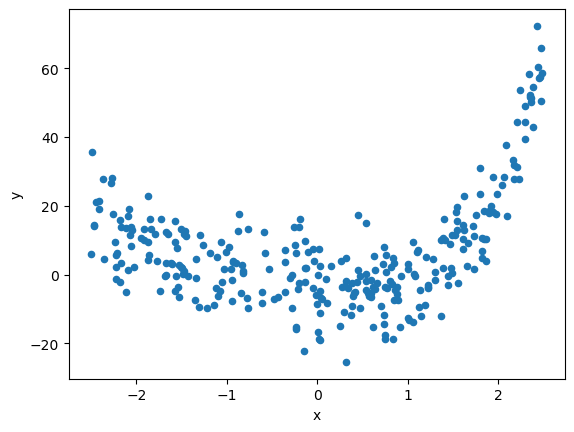

In [2]:
size = 300
X = np.random.rand(size)*5-2.5
w4, w3, w2, w1, w0 = 1, 2, 1, -4, 2
y = w4*(X**4) + w3*(X**3) + w2*(X**2) + w1*X + w0 + np.random.randn(size)*8-4
df = pd.DataFrame({'x': X, 'y': y})
df.to_csv('dane_do_regresji.csv',index=None)
df.plot.scatter(x='x',y='y')

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X.reshape(-1, 1), y, test_size = 0.2, random_state = 42)

In [4]:
modele = {}
lista = []
MSE = {}

# Regresja liniowa

In [5]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

modele['liniowa'] = lin_reg

MSE['lin_reg'] = [mean_squared_error(y_train, lin_reg.predict(X_train)),
                  mean_squared_error(y_test, lin_reg.predict(X_test))]

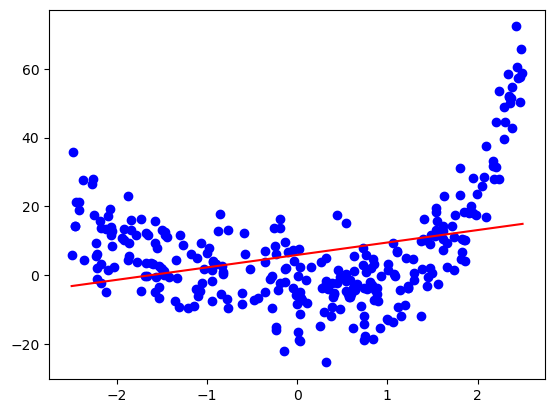

In [6]:
plt.scatter(X, y, c="blue")
X_new = np.arange(-2.5, 2.5, 0.001).reshape(-1,1)
plt.plot(X_new, lin_reg.predict(X_new), c="red")
plt.show()

# KNN

In [7]:
import sklearn.neighbors

## k = 3

In [8]:
knn_reg_3 = sklearn.neighbors.KNeighborsRegressor(n_neighbors=3)
knn_reg_3.fit(X_train, y_train)

modele['knn_3'] = knn_reg_3

MSE['knn_3_reg'] = [mean_squared_error(y_train, knn_reg_3.predict(X_train)),
                    mean_squared_error(y_test, knn_reg_3.predict(X_test))]

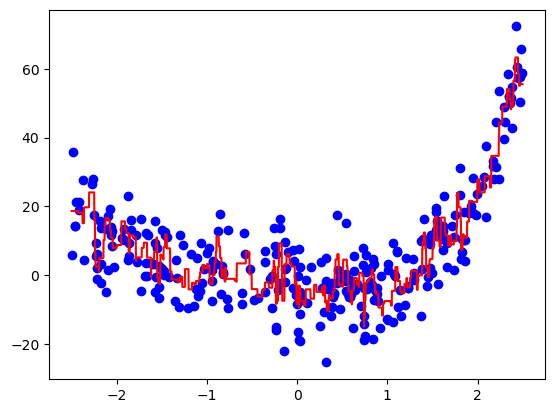

In [9]:
plt.clf()
plt.scatter(X, y, c="blue")
X_new1 = np.arange(-2.5, 2.5, 0.001).reshape(-1,1)
plt.plot(X_new1, knn_reg_3.predict(X_new1), c="red")
plt.show()

## k = 5

In [10]:
knn_reg_5 = sklearn.neighbors.KNeighborsRegressor(n_neighbors=5)
knn_reg_5.fit(X_train, y_train)

modele['knn_5'] = knn_reg_5

MSE['knn_5_reg'] = [mean_squared_error(y_train, knn_reg_5.predict(X_train)),
                    mean_squared_error(y_test, knn_reg_5.predict(X_test))]

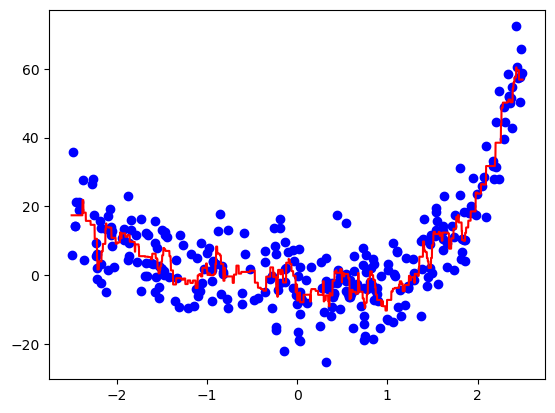

In [11]:
plt.clf()
plt.scatter(X, y, c="blue")
X_new1 = np.arange(-2.5, 2.5, 0.001).reshape(-1,1)
plt.plot(X_new1, knn_reg_5.predict(X_new1), c="red")
plt.show()

# Regresja wielomianowa

In [12]:
from sklearn.preprocessing import PolynomialFeatures

## n = 2

In [13]:
poly_features_2 = PolynomialFeatures(degree=2,include_bias=False)
X_poly_2 = poly_features_2.fit_transform(X_train)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly_2, y_train)

modele['wielomianowa_2'] = (lin_reg_2, poly_features_2)

MSE['poly_2_reg'] = [mean_squared_error(y_train, lin_reg_2.predict(X_poly_2)),
                     mean_squared_error(y_test, lin_reg_2.predict(poly_features_2.fit_transform(X_test)))]

## n = 3

In [14]:
poly_features_3 = PolynomialFeatures(degree=3,include_bias=False)
X_poly_3 = poly_features_3.fit_transform(X_train)
lin_reg_3 = LinearRegression()
lin_reg_3.fit(X_poly_3, y_train)

modele['wielomianowa_3'] = (lin_reg_3, poly_features_3)

MSE['poly_3_reg'] = [mean_squared_error(y_train, lin_reg_3.predict(X_poly_3)),
                     mean_squared_error(y_test, lin_reg_3.predict(poly_features_3.fit_transform(X_test)))]

## n = 4

In [15]:
poly_features_4 = PolynomialFeatures(degree=4,include_bias=False)
X_poly_4 = poly_features_4.fit_transform(X_train)
lin_reg_4 = LinearRegression()
lin_reg_4.fit(X_poly_4, y_train)

modele['wielomianowa_4'] = (lin_reg_4, poly_features_4)

MSE['poly_4_reg'] = [mean_squared_error(y_train, lin_reg_4.predict(X_poly_4)),
                     mean_squared_error(y_test, lin_reg_4.predict(poly_features_4.fit_transform(X_test)))]

## n = 5

In [24]:
poly_features_5 = PolynomialFeatures(degree=5,include_bias=False)
X_poly_5 = poly_features_5.fit_transform(X_train)
lin_reg_5 = LinearRegression()
lin_reg_5.fit(X_poly_5, y_train)

modele['wielomianowa_5'] = (lin_reg_5, poly_features_5)

MSE['poly_5_reg'] = [mean_squared_error(y_train, lin_reg_5.predict(X_poly_5)),
                     mean_squared_error(y_test, lin_reg_5.predict(poly_features_5.fit_transform(X_test)))]

# Porównanie wyników

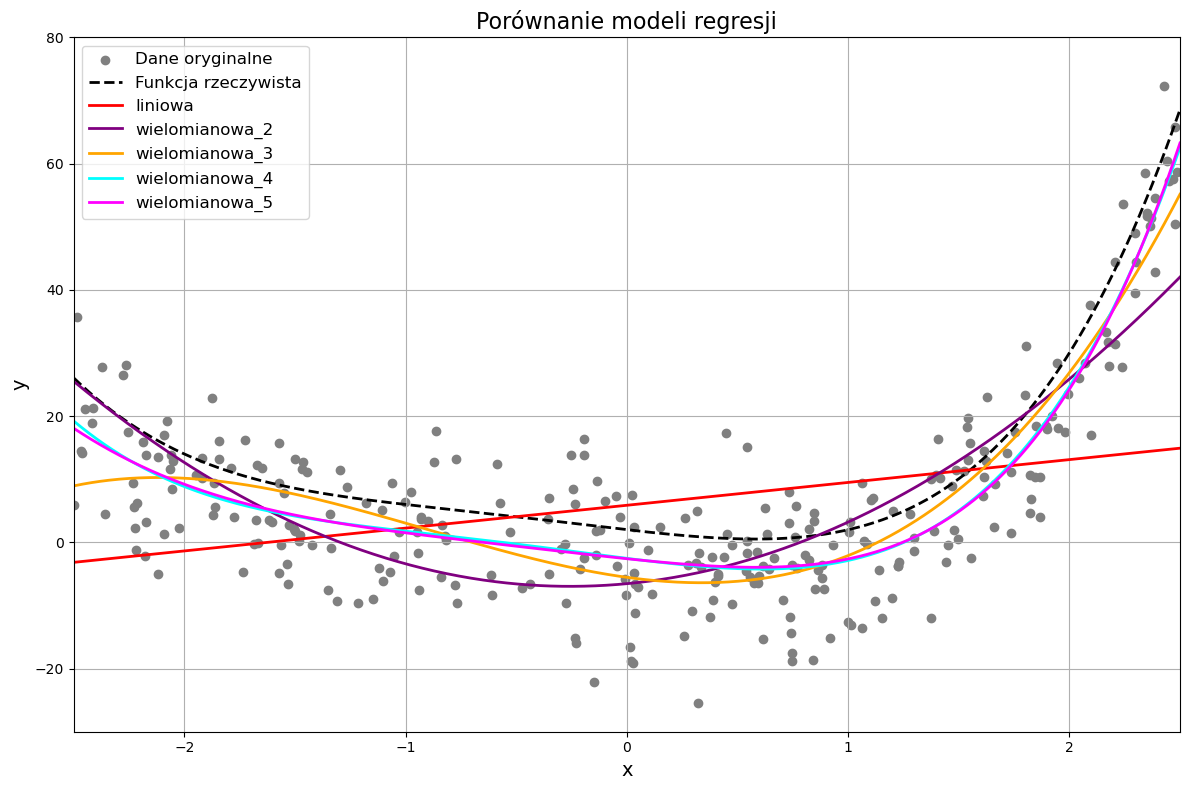

In [25]:
X_plot = np.linspace(-2.5, 2.5, 1000).reshape(-1, 1)
plt.figure(figsize=(12, 8))
plt.scatter(X, y, color='gray', label='Dane oryginalne')
X_true = np.linspace(-2.5, 2.5, 1000)
y_true = w4*(X_true**4) + w3*(X_true**3) + w2*(X_true**2) + w1*X_true + w0
plt.plot(X_true, y_true, 'k--', linewidth=2, label='Funkcja rzeczywista')
colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta']

for i, (name, model) in enumerate(modele.items()):
    if 'knn' in name:
        lista.append((model, None))
    elif 'wielomianowa' not in name:
        lista.append((model, None))
        y_plot = model.predict(X_plot)
        plt.plot(X_plot, y_plot, color=colors[i], linewidth=2, label=name)
    else:
        lista.append((model[0], model[1]))
        X_poly_plot = model[1].transform(X_plot)
        y_plot = model[0].predict(X_poly_plot)
        plt.plot(X_plot, y_plot, color=colors[i], linewidth=2, label=name)

plt.title('Porównanie modeli regresji', fontsize=16)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.xlim(-2.5, 2.5)
plt.ylim(-30, 80)
plt.tight_layout()
plt.show()

# Zapisanie do plików

In [18]:
with open('reg.pkl', 'wb') as file:
    pickle.dump(lista, file)

In [19]:
MSE_df = pd.DataFrame.from_dict(MSE, orient='index', columns=['train_mse', 'test_mse'])

MSE_df.to_pickle('mse.pkl')

In [26]:
MSE_df

,train_mse,test_mse
lin_reg,235.878771,274.490542
knn_3_reg,42.809800,61.410901
knn_5_reg,54.503339,56.392568
poly_2_reg,100.605332,74.676884
poly_3_reg,73.483461,55.417052
poly_4_reg,65.365462,44.706975
poly_5_reg,65.284247,45.176158
